This notebook contains the code for the GRB + afterglow memory timeseries and the Fourier transform of the memory signal. The code is organized in the following way:
1. GRB + afterglow memory timeseries
2. Fourier transform of the memory signal

The analytical formula for the memory signal is taken from the paper [Low-frequency gravitational wave memory from gamma-ray burst afterglows with energy injection](https://arxiv.org/pdf/2301.12590) eq. (17) and eq. (18) for the temporal and frequency domain respectively.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import utils_GRB_afterglow_phenom as us 
import importlib
importlib.reload(us)

<module 'utils_GRB_afterglow_phenom' from '/home/stu_brabant/Memory_effect/LISA_GRB/utils_GRB_afterglow_phenom.py'>

# 1. GRB + afterglow memory timeseries

## 1.1 Context and formulation

Since the GRB and the afterglow originate from the same source, it is convenient to write an unique expression of the memory evolution $h(t)$. Although the duration of the GRB is in the order of seconds to hundreds of seconds, the ejection of matter giving rise to the memory effect is assumed to be around one tenth of a millisecond. It is therefore assumed that the jump associated with the GRB is so rapid that it saturates directly at the value $\Delta h_{\rm GRB}$. To account for the afterglow, the constant value of the GRB memory is coupled to a uniform growth of the afterglow memory $\Delta h_{\rm afterglow}$ with a characteristic time $\tau_m$. The expression of the temporal evolution of the GRB memory and afterglow reads:

\begin{equation}
    h(t,r, \theta) = 
\begin{cases}
    0 & t \le t_{\text{start}}\\
    \Delta h_{\rm GRB} +\Delta h_{\rm afterglow} (t/\tau_m) & t_{\text{start}} < t \le \tau_m\\
    \Delta h_{\rm GRB} + \Delta h_{\rm afterglow} \,  & t > \tau_m 
\end{cases}
\end{equation}

with $\tau_m = T_{\rm end} + R_{\rm end} (1-\cos\theta)/c$ for a non-cosmological source and $t_{\rm start}$ is the time at which the GRB start emitting ($t_{\rm start} = 0$). $R_{\rm end}$ is the distance of the jet to the source at the end of the GRB prompt emission, $T_{\rm end}$ is the duration of the GRB prompt emission, $\theta$ is the angle between the jet axis and the line of sight, and $c$ is the speed of light.

## 1.2 $\Delta h_{\rm GRB}$

For the case of the GRB memory, we analyze the contribution of a single point-mass (either than the jet) undergoing an instantaneous acceleration from 0 to $\beta$ and associated to the total duration and energy of the burst with amplitude $\Delta h_{\rm GRB}$. The change in the metric reads:
\begin{equation}
    \Delta h_{\text{GRB}} = \frac{2 E_j \beta^2}{r } ~\frac{\sin^2\theta}{1-\beta \cos\theta}\ ,
\end{equation}
where $E_j$ is the jet energy, $\beta = v/c\sim 1$ the jet velocity, $r$ the source distance, and $\theta$ the viewing angle from the jet axis. We acknowledge that this model is simplified. It neglects the acceleration time (approximately 0.1 milliseconds) and reduces the jet to a point, ignoring its actual thickness.

This value of $\Delta h_{\rm GRB}$ is provided by the function ```memory_initial_acceleration_GRB``` given the previous parameters. 

In [73]:
us.memory_initial_acceleration_GRB?

Signature: us.memory_initial_acceleration_GRB(Ej, theta_ej, phi_ej, d, beta=0.99)
Docstring:
Initial memory from the jet acceleration phase (Eq. 11) of https://arxiv.org/pdf/2301.12590: h_in
The jets are assumed to be instantaneously accelerated.
Paramètres:
-----------
Ej : float
    Total kinetic energy of the jet [erg]
theta_ej : float
    Viewing angle (angle between jet axis and line of sight) [rad]
phi_ej : float
    Azimuthal angle of the jet in the plane of the sky [rad]
d : float
    Distance to the source [pc]
beta : float
    Normalized velocity of the jet (v/c), typically close to 1 for (ultra)relativistic jets

Returns:
---------
h_in : float
    Amplitude of the initial memory from the jet acceleration phase
File:      ~/Memory_effect/LISA_GRB/utils_GRB_afterglow_phenom.py
Type:      function

## 1.3 $\Delta h_{\rm afterglow}$

In the context where the afterglow is powered solely by the synchrotron emission of accelerated electrons, the contribution of the afterglow to the memory is expressed as~\cite{afterglow_170817}:
\begin{equation}
    \Delta h_{\text{afterglow}} = \frac{ P_{\text{in}}T_{\text{end}} \beta^2}{r}~\frac{\sin^2\theta_{\rm ej}~(1-\cos{\theta_j})}{1-\beta \cos(\theta_{\rm ej})}\ , 
\end{equation}
with $ P_{\text{in}}$ the power of energy injection from synchrotron emission, $T_{\text{end}}$ the duration of the prompt emission of the GRB defined by an on-axis observer, $\theta$ the viewing angle and $\theta_j$ the half-opening angle of the jet.

The function ```memory_afterglow_injection``` provides the value of $\Delta h_{\rm afterglow}$ given the previous parameters.

In [74]:
us.memory_afterglow_injection?

Signature: us.memory_afterglow_injection(Pin, T_end, theta_ej, theta_j, d, beta=0.99)
Docstring:
    Additional memory from the afterglow injection phase  https://arxiv.org/pdf/2301.12590: h_m 
    Arise from the continuous energy injection into the external medium by the jet after the initial acceleration phase.
    The GW signals in GRB afterglows originate from the shock-accelerated ISM and the synchrotrons emission.
    Parameters:
-----------
    Pin : float
        Power of the energy injection [erg/s] ~ 10^48- 10^50 erg/s
    T_end : float
        Duration of the energy injection phase [s] ~ 10^2 - 10^3 s =? Duration of the burst in the observer frame
    theta_ej : float
        Viewing angle (angle between jet axis and line of sight) [rad]
    theta_j : float
        Jet opening angle [rad]
        theta_j = theta_ej / 2
    d : float
        Distance to the source [pc]
    beta : float
        Normalized velocity of the jet (v/c), typically close to 1 for (ultra)relativistic 

## 1.4 Total memory timeseries

The total memory timeseries is given by the function ```memory_total_waveform``` which takes as input:
- t_obs: the time array of the memory timeseries
- h_in: the initial memory from the GRB
- h_m: the additional memory from the afterglow injection
- t_end_injection: the duration of the prompt emission of the GRB defined by an on-axis observer, $T_{\rm end}$
- theta_ej: the viewing angle of the jet
- radius: the distance from the source to the jet at the end of the GRB prompt emission, $R_{\rm end}$. Set at 0.01 pc.

returns the timeseries of the total memory signal over the time array t_obs:

In [75]:
us.memory_total_waveform?

Signature:
us.memory_total_waveform(
    t_obs,
    h_in,
    h_m,
    t_end_injection,
    theta_ej,
    radius=0.01,
)
Docstring:
Total memory waveform combining the initial acceleration and afterglow injection phases
Parameters:
-----------
t_obs : array-like
    Time array for the observed memory signal [s]
h_in : float
    Initial memory amplitude from the jet acceleration phase
h_m : float
    Additional memory amplitude from the afterglow injection phase
t_end_injection : float
    Characteristic timescale for the afterglow injection phase (duration over which h_m is accumulated) [s]
theta_ej : float
    Viewing angle (angle between jet axis and line of sight) [rad]
radius : float [pc]
    Characteristic radius for the afterglow shock (in parsecs) used to estimate the timescale t_m for the memory to reach its maximum value. Default is 0.01 [pc]

--------
Returns:
t_obs : array-like
    Time array for the observed memory signal [s]
h_total : array-like
    Total memory signal com

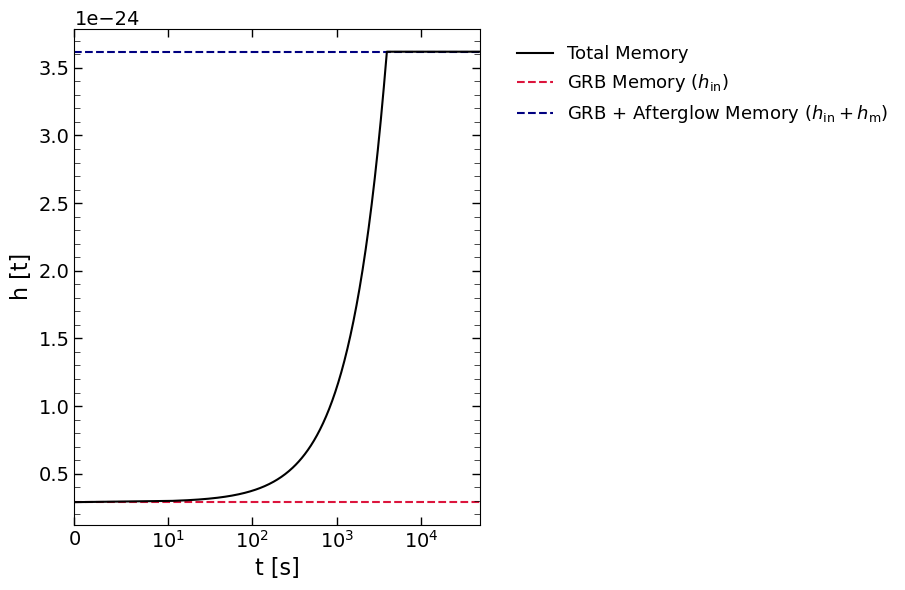

In [76]:
# 1. GRB memory 
h_in = us.memory_initial_acceleration_GRB(Ej=1e51, theta_ej=np.deg2rad(5), phi_ej=0, d=100 * 1e6, beta=0.99)
# 2. Afterglow memory
h_m = us.memory_afterglow_injection(Pin=1e52, T_end=200, theta_ej=np.pi/4, theta_j=np.deg2rad(5), d=100 * 1e6, beta=0.99)
# 3. Total memory timeseries
t_obs = np.logspace(-4, 5, 1000)  # from 0.1 ms to 10 ks
t_mem, h_total = us.memory_total_waveform(t_obs, h_in, h_m, t_end_injection=10, theta_ej=np.deg2rad(5))

# plot
plt.figure(figsize=(5, 6))
plt.plot(t_mem, h_total, label='Total Memory', color='k')
plt.axhline(h_in, color='crimson', linestyle='--', label=r'GRB Memory ($h_{\rm in}$)', zorder=0)
plt.axhline(h_in + h_m, color='navy', linestyle='--', label=r'GRB + Afterglow Memory ($h_{\rm in} + h_{\rm m}$)', zorder=0)
plt.xscale('symlog', linthresh=10, linscale=1)
plt.xlim(0, 5e4)
plt.xlabel('t [s]')
plt.ylabel('h [t]')
plt.tight_layout()
plt.legend(loc='upper left', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1))
plt.show()

# 2. Fourier transform of the memory signal

## 2.1 FT of the total memory signal

The Fourier transform of such a signal is given without proof by the following expression: 

\begin{equation}
    |\tilde{h}(f)|^2 = 4 a^2 \sin^4{(\pi f \tau_m)} + [a\sin{(2\pi f \tau_m)} + b^2]
\end{equation}
with $a = \Delta h_{\rm afterglow} / 4\pi^2 f^2 \tau_m$ and $b = \Delta h_{\rm GRB}/2\pi f$. The function ```total_waveform_fft``` computes the Fourier transform of the total memory signal given the previous parameters.

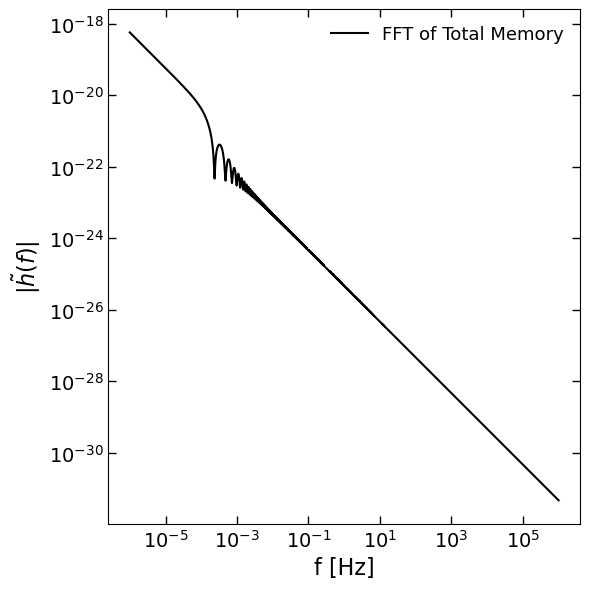

In [77]:
f, tf = us.total_waveform_fft(h_in, h_m, t_end_injection=10, theta_ej=np.deg2rad(5), radius=0.01)
plt.figure(figsize=(6, 6))
plt.loglog(f, tf, label='FFT of Total Memory', color='k')
plt.xlabel('f [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|$')
plt.tight_layout()
plt.legend(loc='upper right', frameon=False, fontsize=13)
plt.show()


Here we compute some waveform and its Fourier transform to check that the analytical expression of the Fourier transform is correct for different value of $E_j$ and $P_{\rm in}$. 

Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: 1.56e+04 s
Time of the transition between the GRB memory and the afterglow memory: 1.58e+04 s
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24
Initial memory amplitude from the GRB: 6.32e-24


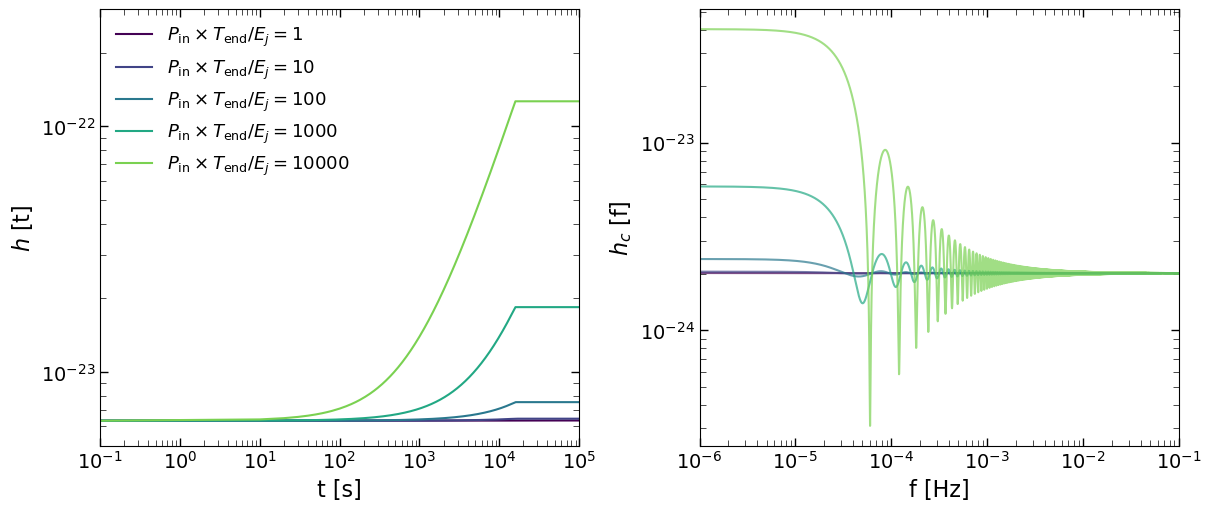

In [ ]:
from lal import PC_SI, C_SI
# Parameters for the GRB and afterglow memory
E_j = 1e50
theta_j = np.deg2rad(5)
theta_v = np.deg2rad(5)
theta_ej = np.deg2rad(10)
phi_ej = 0.0
beta = 0.99
r = 1e6            # 1 Mpc 
tau_grb_s = 1e-3   
end_grb_s = 200.0  

# Ratios for P_in / E_j
ratios = np.logspace(0, 4, 5)
t = np.linspace(0.1, 1e6, int(1e5))

t_end_afterglow_prop = ( (0.01 * PC_SI) * (1-np.cos(theta_ej)) )/ C_SI
print(f"Associated timescale for the propagation of the FS afterglow with a radius of 0.01 pc: {t_end_afterglow_prop:.2e} s")
t_m = end_grb_s + t_end_afterglow_prop
print(f"Time of the transition between the GRB memory and the afterglow memory: {t_m:.2e} s")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for idx, ratio in enumerate(ratios):
    h_in = us.memory_initial_acceleration_GRB(E_j, theta_ej, phi_ej, r, beta)
    print(f"Initial memory amplitude from the GRB: {h_in:.2e}")
    # Afterglow power as a fraction of E_j per second
    P_in = E_j * ratio / end_grb_s # divide by end_grb_s to have the same order of magnitude for the memory amplitude
    # Afterglow memory amplitude
    h_afterglow = us.memory_afterglow_injection(P_in, end_grb_s, theta_ej, theta_j, r, beta)
    t, h_tot,  = us.memory_total_waveform(t, h_in, h_afterglow, end_grb_s, theta_ej)
    f, fft = us.total_waveform_fft(h_in, h_afterglow, end_grb_s, theta_ej)
    label = f'$P_{{\\mathrm{{in}}}} \\times T_{{\\mathrm{{end}}}}/E_j={ratio:.0f}$'
    ax1.plot(t, h_tot, color=plt.cm.viridis(idx / len(ratios)), label=label)
    ax2.loglog(f, 2*f*np.abs(fft), label=label, color=plt.cm.viridis(idx / len(ratios)), alpha=0.7)
    
ax1.set_xlabel('t [s]')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5e-24, 3e-22)
ax1.minorticks_on()
ax1.set_ylabel(r'$h$ [t]')

ax1.set_xlim(0.1, 1e5)

ax2.set_xlabel('f [Hz]')
ax2.set_ylabel(r'$h_c$ [f]')

ax2.set_xlim(1e-6, 1e-1)

ax1.legend(loc='upper left', frameon=False, fontsize = 13)

plt.show()

The above figure reveals how the relative contributions of the GRB and afterglow components depends on their amplitudes. When $\Delta h_{\rm afterglow} \ll \Delta h_{\rm GRB}$, the afterglow contribution is negligible, and the memory signal remains constant in both time and frequency domains, entirely dominated by the jet component. However, when the afterglow becomes non-negligible ($P_{\rm in} \times T_{\rm end} \sim 10^3 E_{\rm j}$), the memory exhibits additional features: a rising phase associated with the afterglow emission, and a more pronounced decay in the frequency domain (following a $1/f$ dependence) superimposed on the constant plateau from the GRB. The transition between these jet-dominated and afterglow-dominated regimes is reflected by the ration $P_{\rm in} \times T_{\rm end}/ E_{\rm j}$.
